In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load
!pip install resampy

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import librosa
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential,Model
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D, Flatten, Dropout
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from sklearn.preprocessing import LabelEncoder,StandardScaler
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory



# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 27.5 MB/s eta 0:00:0000:0100:01


2024-08-04 22:57:18.013151: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-08-04 22:57:18.013265: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-08-04 22:57:18.166902: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [ ]:
# Load metadata
metadata_path = '/kaggle/input/coughvid-wav/public_dataset/metadata_compiled.csv'
metadata = pd.read_csv(metadata_path)

# Path to audio files
audio_dir = '/kaggle/input/coughvid-wav/public_dataset/'

metadata.head()

,uuid,datetime,cough_detected,SNR,latitude,longitude,age,gender,respiratory_condition,fever_muscle_pain,...,quality_4,cough_type_4,dyspnea_4,wheezing_4,stridor_4,choking_4,congestion_4,nothing_4,diagnosis_4,severity_4
0,00014dcc-0f06-4c27-8c7b-737b18a2cf4c,2020-11-25T18:58:50.488301+00:00,0.0155,7.326171,48.9,2.4,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,00039425-7f3a-42aa-ac13-834aaa2b6b92,2020-04-13T21:30:59.801831+00:00,0.9609,16.151433,31.3,34.8,15.0,male,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0007c6f1-5441-40e6-9aaf-a761d8f2da3b,2020-10-18T15:38:38.205870+00:00,0.1643,16.217201,NaN,NaN,46.0,female,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0009eb28-d8be-4dc1-92bb-907e53bc5c7a,2020-04-12T04:02:18.159383+00:00,0.9301,20.146058,40.0,-75.1,34.0,male,True,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0012c608-33d0-4ef7-bde3-75a0b1a0024e,2020-04-15T01:03:59.029326+00:00,0.0482,0.000000,-16.5,-71.5,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
metadata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27550 entries, 0 to 27549
Data columns (total 51 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   uuid                   27550 non-null  object 
 1   datetime               27550 non-null  object 
 2   cough_detected         27550 non-null  float64
 3   SNR                    27550 non-null  float64
 4   latitude               16084 non-null  float64
 5   longitude              16084 non-null  float64
 6   age                    15218 non-null  float64
 7   gender                 16224 non-null  object 
 8   respiratory_condition  16224 non-null  object 
 9   fever_muscle_pain      16224 non-null  object 
 10  status                 16224 non-null  object 
 11  quality_1              820 non-null    object 
 12  cough_type_1           802 non-null    object 
 13  dyspnea_1              820 non-null    object 
 14  wheezing_1             820 non-null    object 
 15  st

In [ ]:
metadata=metadata[['uuid', 'cough_detected','status']]
metadata.dropna()
metadata.head()

,uuid,cough_detected,status
0,00014dcc-0f06-4c27-8c7b-737b18a2cf4c,0.0155,NaN
1,00039425-7f3a-42aa-ac13-834aaa2b6b92,0.9609,healthy
2,0007c6f1-5441-40e6-9aaf-a761d8f2da3b,0.1643,healthy
3,0009eb28-d8be-4dc1-92bb-907e53bc5c7a,0.9301,healthy
4,0012c608-33d0-4ef7-bde3-75a0b1a0024e,0.0482,NaN


/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


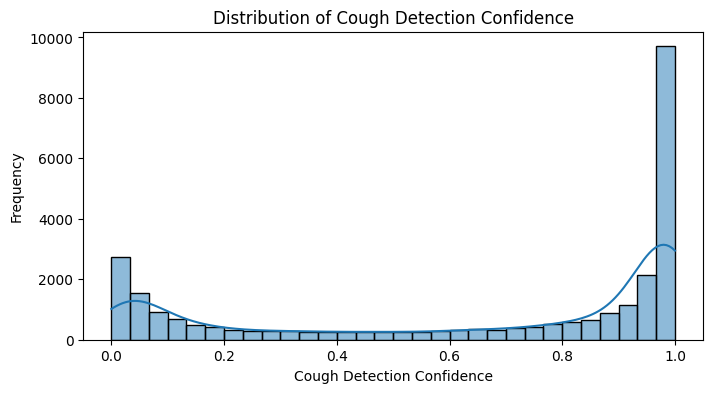

In [ ]:
plt.figure(figsize=(8, 4))
sns.histplot(metadata['cough_detected'], bins=30, kde=True)
plt.title('Distribution of Cough Detection Confidence')
plt.xlabel('Cough Detection Confidence')
plt.ylabel('Frequency')
plt.show()

In [ ]:

def audio_to_spectrogram(file_path, max_pad_len=174):
    try:
        audio, sample_rate = librosa.load(file_path, res_type='kaiser_fast')
        spectrogram = librosa.feature.melspectrogram(y=audio, sr=sample_rate, n_mels=128, fmax=8000)
        spectrogram = librosa.power_to_db(spectrogram)
        spectrogram = spectrogram.astype(np.float32)

        # Padding if necessary to ensure each spectrogram has the same size
        pad_width = max_pad_len - spectrogram.shape[1]
        if pad_width > 0:
            spectrogram = np.pad(spectrogram, pad_width=((0, 0), (0, pad_width)), mode='constant')
        else:
            spectrogram = spectrogram[:, :max_pad_len]
    except Exception as e:
        print(f"Error encountered while processing file {file_path}: {e}")
        return None
    return spectrogram

In [ ]:
# Extract features and labels
features = []
labels = []

sampled_metadata = metadata.sample(n=1000, random_state=42)  # sampled 1000 files because it was taking long to run
for _, row in sampled_metadata.iterrows():
    file_path = f'{audio_dir}{row["uuid"]}.wav'
    spectrogram = audio_to_spectrogram(file_path)
    if spectrogram is not None:
        features.append(spectrogram)
        labels.append(row['status'])

# Encode labels
encoder = LabelEncoder()
labels_encoded = encoder.fit_transform(labels)

In [ ]:
def build_model(input_shape):
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    predictions = Dense(1, activation='sigmoid')(x)
    model = Model(inputs=base_model.input, outputs=predictions)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Prepare input data for ResNet50
features = np.array(features)
features = np.stack([features]*3, axis=-1)

# Split data
X_train, X_test, y_train, y_test = train_test_split(features, labels_encoded, test_size=0.2, random_state=42)

# Model configuration
input_shape = (X_train.shape[1], X_train.shape[2], 3)
model = build_model(input_shape)

In [ ]:
#Model Training
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 177s 6s/step - accuracy: 0.4288 - loss: -12.4757 - val_accuracy: 0.4500 - val_loss: -464844.7188
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 136s 5s/step - accuracy: 0.4498 - loss: -55.8556 - val_accuracy: 0.4500 - val_loss: -12717.8359
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 136s 5s/step - accuracy: 0.4492 - loss: -108.2590 - val_accuracy: 0.4500 - val_loss: -63.4941
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 143s 5s/step - accuracy: 0.4717 - loss: -156.2823 - val_accuracy: 0.4500 - val_loss: -146.0736
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 137s 5s/step - accuracy: 0.4364 - loss: -231.5744 - val_accuracy: 0.4500 - val_loss: -923.3186
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 137s 5s/step - accuracy: 0.4485 - loss: -265.3456 - val_accuracy: 0.4500 - val_loss: -454.8034
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 143s 6s/step - accuracy: 0.4284 - loss: -314.4213 - val_accuracy: 0.4500 - val_loss: -277.3039
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 138s 6s/step - accuracy: 0.46

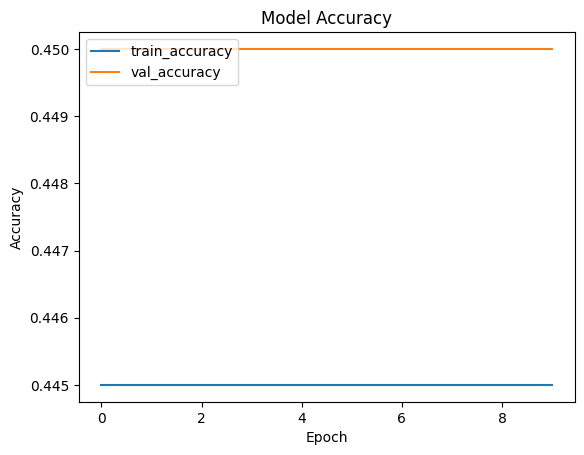

In [ ]:
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc="upper left")
plt.show()

7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 977ms/step
Classification Report:
               precision    recall  f1-score   support

    COVID-19       0.03      1.00      0.05         5
     healthy       0.00      0.00      0.00        90
         nan       0.00      0.00      0.00        84
 symptomatic       0.00      0.00      0.00        21

    accuracy                           0.03       200
   macro avg       0.01      0.25      0.01       200
weighted avg       0.00      0.03      0.00       200



/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


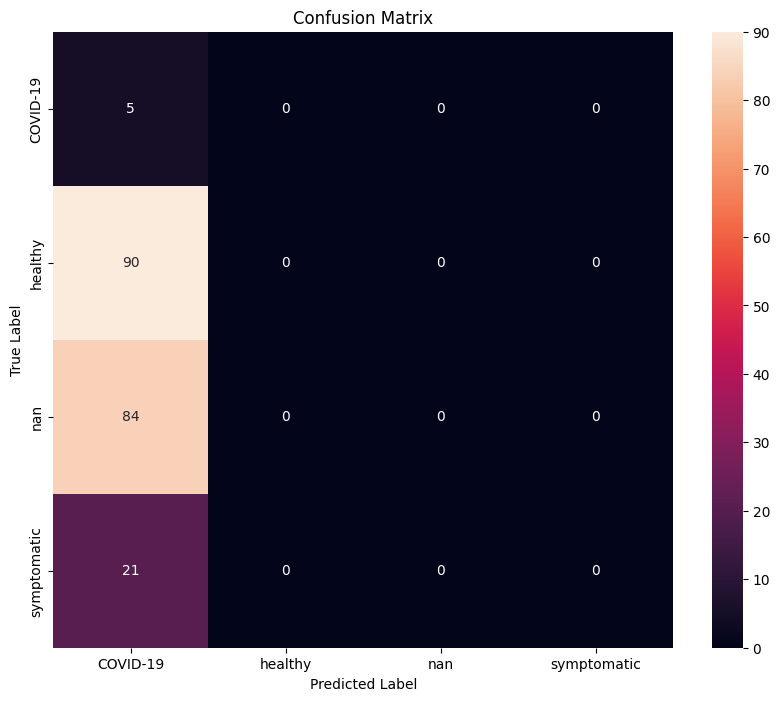

In [ ]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = y_test

class_labels = encoder.classes_
# Generate a classification report
class_report = classification_report(y_true, y_pred_classes, target_names=class_labels)
print("Classification Report:\n", class_report)

# Compute confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()
